# Experimental Plan

This notebook evaluates the greedy scheduling algorithm against a random baseline. The goal is to compare performance across multiple metrics and observe consistency and variability in results.

In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
from src.loader import load_exercises, load_request
from src.scheduler import build_greedy_plan, build_random_plan
from src.evaluator import evaluate_weekly_plan


In [3]:
exercises = load_exercises("../data/exercises.json")
request = load_request("../data/sample_request.json")
lookup = {ex.id: ex for ex in exercises}

print(f"Loaded {len(exercises)} exercises")
print(request)

Loaded 10 exercises
PlanningRequest(days_available=['Monday', 'Wednesday', 'Friday'], session_time_limit=30, goal='strength', required_categories=['squat', 'hinge', 'push', 'pull', 'core'], daily_fatigue_cap=16, equipment_available=['barbell', 'rack', 'bench', 'pullup_bar', 'dumbbells'], excluded_exercises=[], preferred_exercises=['Back Squat', 'Pull-Up'])


In [4]:
greedy_plan = build_greedy_plan(exercises, request)
greedy_metrics = evaluate_weekly_plan(greedy_plan, request, lookup)

greedy_metrics

{'coverage_score': 1.0,
 'priority_score': 0.9333333333333333,
 'time_utilization_score': 0.7222222222222222,
 'fatigue_balance_score': 0.1111111111111111,
 'constraint_violations': 0,
 'total_score': 70.55555555555554}

In [5]:
random_scores = []
random_metric_rows = []

for seed in range(30):
    plan = build_random_plan(exercises, request, seed=seed)
    metrics = evaluate_weekly_plan(plan, request, lookup)
    random_scores.append(metrics["total_score"])
    random_metric_rows.append(metrics)

print("Greedy total score:", greedy_metrics["total_score"])
print("Random average total score:", sum(random_scores) / len(random_scores))
print("Random best total score:", max(random_scores))
print("Random worst total score:", min(random_scores))

Greedy total score: 70.55555555555554
Random average total score: 73.5009182375265
Random best total score: 92.77777777777777
Random worst total score: 66.16200169635285


In [6]:
import statistics

print("Random score standard deviation:", statistics.pstdev(random_scores))

Random score standard deviation: 7.004608560224265


## Notes

The greedy planner is expected to produce more consistent plans than the random baseline because it uses a heuristic scoring function rather than unguided feasible selection.

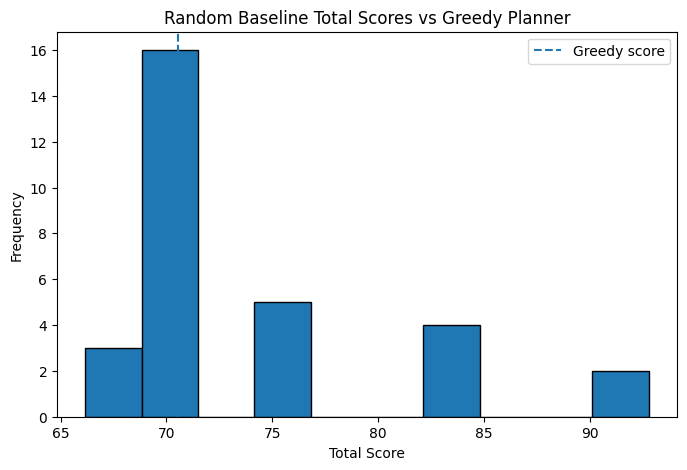

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(random_scores, bins=10, edgecolor="black")
plt.axvline(greedy_metrics["total_score"], linestyle="--", label="Greedy score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.title("Random Baseline Total Scores vs Greedy Planner")
plt.legend()
plt.show()

## Results Interpretation

The distribution of random baseline scores appears tightly clustered, with the greedy algorithm producing a similar overall score. This indicates that the current evaluation metrics primarily capture aggregate properties such as total priority, coverage, and workload, but do not fully differentiate between structurally different schedules.

Although the greedy and random planners generate different exercise arrangements, these differences are not strongly reflected in the scoring system. This suggests that additional metrics may be required to capture qualitative aspects such as session structure, exercise ordering, or workload distribution across days.

This observation highlights a limitation of the current evaluation framework and provides a direction for future refinement.